# Business Problem

A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delivery, for products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.

## Desired Outcome:

The goal is to analyze delivery operations, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and improve overall profitability and efficiency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors=cm.viridis(np.linspace(0,1,5))
primary_color=viridis_colors[0]
secondary_color=viridis_colors[1]
accent_color=viridis_colors[2]
danger_color='#800000'
neutral_color=viridis_colors[4]
custom_palette=viridis_colors

In [3]:
df=pd.read_csv('DataCoSupplyChainDataset.csv',encoding='latin-1')

# Exploratory Data Analysis(EDA)
### EDA Findings
- Dataset contains **172,765 orders** spanning **January 2015 – January 2018**.
- Columns with no analytical value or containing PII (`Product Description`, `Product Image`, `Customer Email`, `Customer Password`, `Customer Fname`, etc.) were dropped to keep the dataset clean and safe to share.
- No missing values remained in the fields used for analysis after cleaning; duplicates were checked and handled.
- `Order Processing Time` was derived as the gap between `order date` and `shipping date`, forming the base for all delay calculations that follow.

In [4]:
# Overview
print('rows, cols:',df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:',df.duplicated().sum())
print('\nMissing values(top 20)')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [5]:
# Data Cleaning
columns_to_drop=[
    'Product Description',
    'Product Image',
    'Customer Email', 
    'Customer Fname', 
    'Customer Password', 
    'Customer Lname', 
    'Customer Street', 
    'Customer Zipcode',
    'Latitude', 
    'Longitude',
    'Order Zipcode',
    'Order Item Product Price', 
    'Order Item Cardprod Id', 
    'Order Item Discount', 
    'Order Item Discount Rate', 
    'Order Item Id',
    'Order Id',
    'Order Item Quantity',
    'Order Item Total',
    'Department Id',
    'Category Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id', 
    'Product Category Id', 
    'Product Status', 
    'Benefit per order', #identical to Order Profit per Order
    'Product Status', #have only one valve
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

# drop columns with blanks, only one value
df=df.drop(columns=columns_to_drop)

#remove canceled orders as not relevant
df=df[df['Delivery Status']!='Shipping canceled']

# Standard date conversion
for c in ['order date (DateOrders)','shipping date (DateOrders)']:
    df[c]=pd.to_datetime(df[c],errors='coerce',dayfirst=False)

# after data cleaning
print('rows, cols:',df.shape)
print('\nMissing values(top 5)')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)

Missing values(top 5)
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [6]:
# value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique()<10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [7]:
# calculate order processing time and delay
df['Order Processing Time']=(df['shipping date (DateOrders)']-df['order date (DateOrders)']).dt.days
df['Delay']=df['Order Processing Time']-df['Days for shipment (scheduled)']
df['Is_Delayed']=df['Delay']>0
df['order_month']=df['order date (DateOrders)'].dt.month
df['order_day']=df['order date (DateOrders)'].dt.day_name()
df['order_hour']=df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [8]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [10]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [11]:
# Profitability flag baseeed on Order Profit Per Order
df['Profitability Flag']=np.where(df['Order Profit Per Order']>0, 'Profit', np.where(df['Order Profit Per Order']<0, 'Loss','Break-even'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

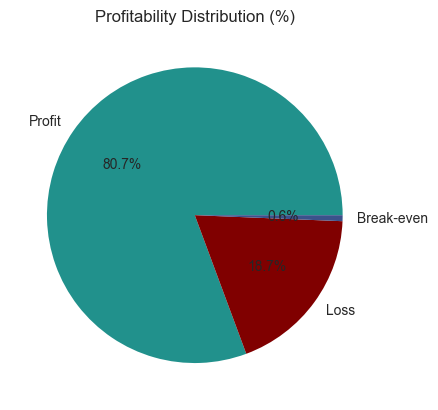

In [12]:
# Visualization of Profitability distribution
profit_count=df['Profitability Flag'].value_counts(normalize=True)*100
profit_count.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color,danger_color,secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

# Business KPIs
Baseline performance metrics computed directly from the cleaned dataset:

| Metric | Value |
|---|---|
| Total Orders | 172,765 |
| Late Deliveries | 94,523 |
| **Late Delivery Rate** | **54.71%** |
| On-Time Delivery Rate | 45.29% |
| Total Profit (profitable orders) | $7.5M |
| Profit at Risk (delayed orders) | $2.1M |
| 90th Percentile Delay | 3 days |
| Avg Order Profit | $22.03 |

**Key takeaway:** more than half of all orders arrive late — this isn't an edge case, it's the default customer experience. The fact that even the 90th-percentile delay is only 3 days suggests this is a systemic, process-driven problem rather than a handful of catastrophic failures.

In [13]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}k $'
    else:
        return f'{value:.0f} $'

delayed_df=df[df['Delay']>0]
metrics={}
metrics['Total Orders']=  len(df)
metrics['Late Deliveries']= len(delayed_df)
metrics['90% Delay (days)']= delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %']= (1-float(metrics['Late Deliveries']) / metrics['Total Orders'])*100
metrics['Late Delivery %']= float(metrics['Late Deliveries']) / metrics['Total Orders']*100
metrics['Total Profit']=format_func(df.loc[df['Order Profit Per Order']>0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays']=format_func(df.loc[df['Delay']>0, 'Order Profit Per Order'].sum())

print('\n--- Business KPIs ---\n')
for k,v in metrics.items():
    if isinstance(v,float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $



# Profitability vs Delivery Time Analysis
Orders were tiered by `Order Profit Per Order` into Profit / Loss / Break-even, and profit was analyzed against delay length.

**Findings:**
- **80.7%** of orders are profitable, but **18.7%** are loss-making — a meaningful drag that's worth tracking separately from the delay problem.
- Average profit per order stays roughly **flat ($20–$23)** regardless of how many days an order is delayed.
- This is an important distinction: **the profitability problem is driven by the volume of delayed orders, not by delayed orders being individually less profitable.** That makes fixing *throughput* (fewer delays overall) the highest-leverage lever — not renegotiating margins on late orders.
- **31.0%** of all orders are delayed by exactly 1 day — the single largest cohort — and orders delayed 1–4 days account for **54.7%** of volume, which lines up almost exactly with the overall late rate.

In [14]:
profit_metrics=(
    df.groupby('Delay')['Order Profit Per Order']
        .agg(
            mean_profit='mean',
            total_profit='sum',
            order_count='count'
        )
        .reset_index()
)

In [15]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [16]:

delay_distribution=(
    df['Delay'].value_counts(normalize=True).sort_index()*100
).reset_index()

In [17]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


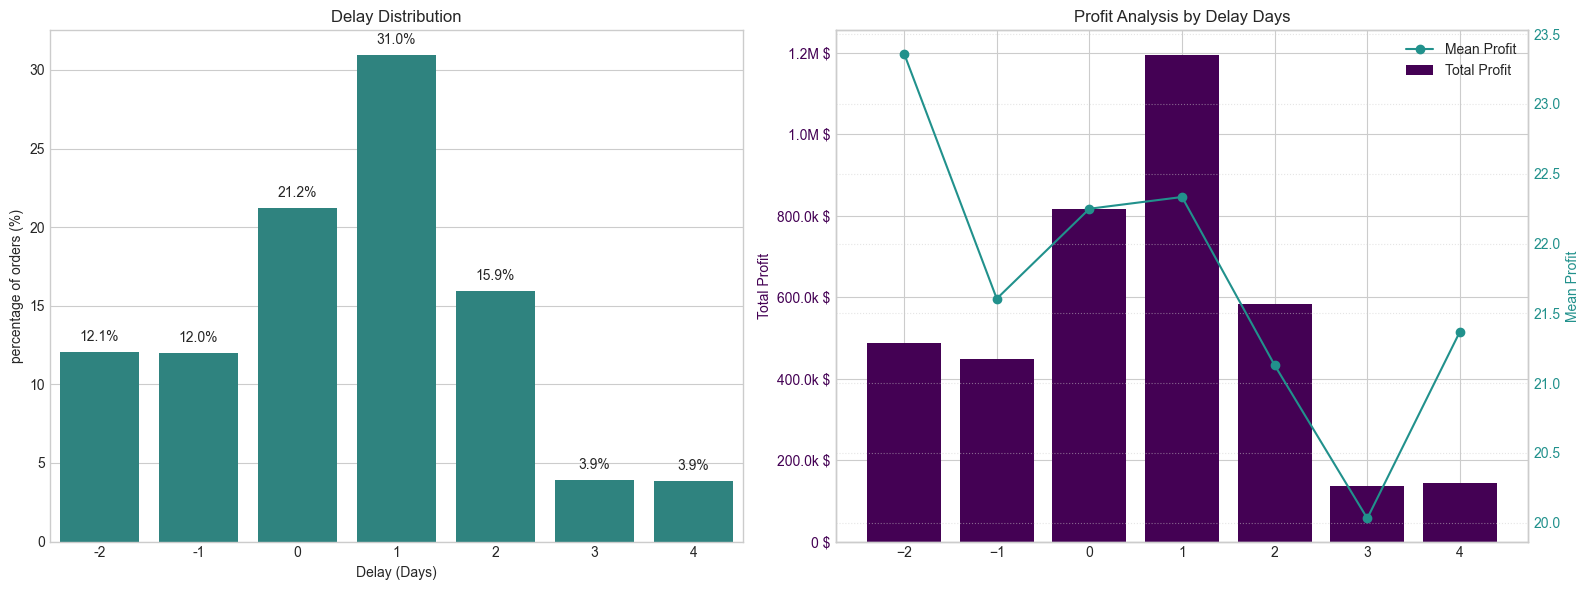

In [18]:

delay_distribution.columns= ['Delay_Days','Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1,ax2)= plt.subplots(1,2, figsize=(16,6))

# First plot: Delay Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (Days)')
ax1.set_ylabel('percentage of orders (%)')

# percentage text on bars
for bar in ax1.patches:
    height=bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height+0.5, f'{height:.1f}%', ha='center', va='bottom')

# Second plot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3=ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)

# format total profit axis to K $ , M $
def format_func(value,tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}k $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

lines, labels= ax3.get_legend_handles_labels()
lines2, labels2= ax2.get_legend_handles_labels()
ax3.legend(lines+ lines2, labels+labels2, loc="upper right")
ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('Delay Distribution & Profit vs. Delay .png', dpi=300, bbox_inches='tight')
plt.show()

# Bottleneck Detection
Delay percentage was computed across six operational dimensions — Region, Segment, Shipping Mode, Order Status, Payment Type, and Department — to identify where the fulfillment process breaks down most.

**Findings:**
- **Shipping Mode is the #1 lever:** First Class has a **100%** delay rate, Second Class **79.8%**, Standard Class **39.8%**, and Same Day **0%**. Mode assignment logic is the single most impactful variable to fix.
- **Regional spread is narrow (55–59%):** Central Africa leads at 58.7%, but all regions cluster tightly. This rules out a localized logistics failure — it confirms the issue is company-wide and systemic.
- **Customer segments are nearly identical (54.5–55.4%):** Consumer, Corporate, and Home Office all experience the same broken delivery promise — no segment is being prioritized.
- **Health & Beauty (56.9%) and Pet Shop (56.6%)** lead by department, marginally above others — worth an inventory/carrier audit for these categories specifically.

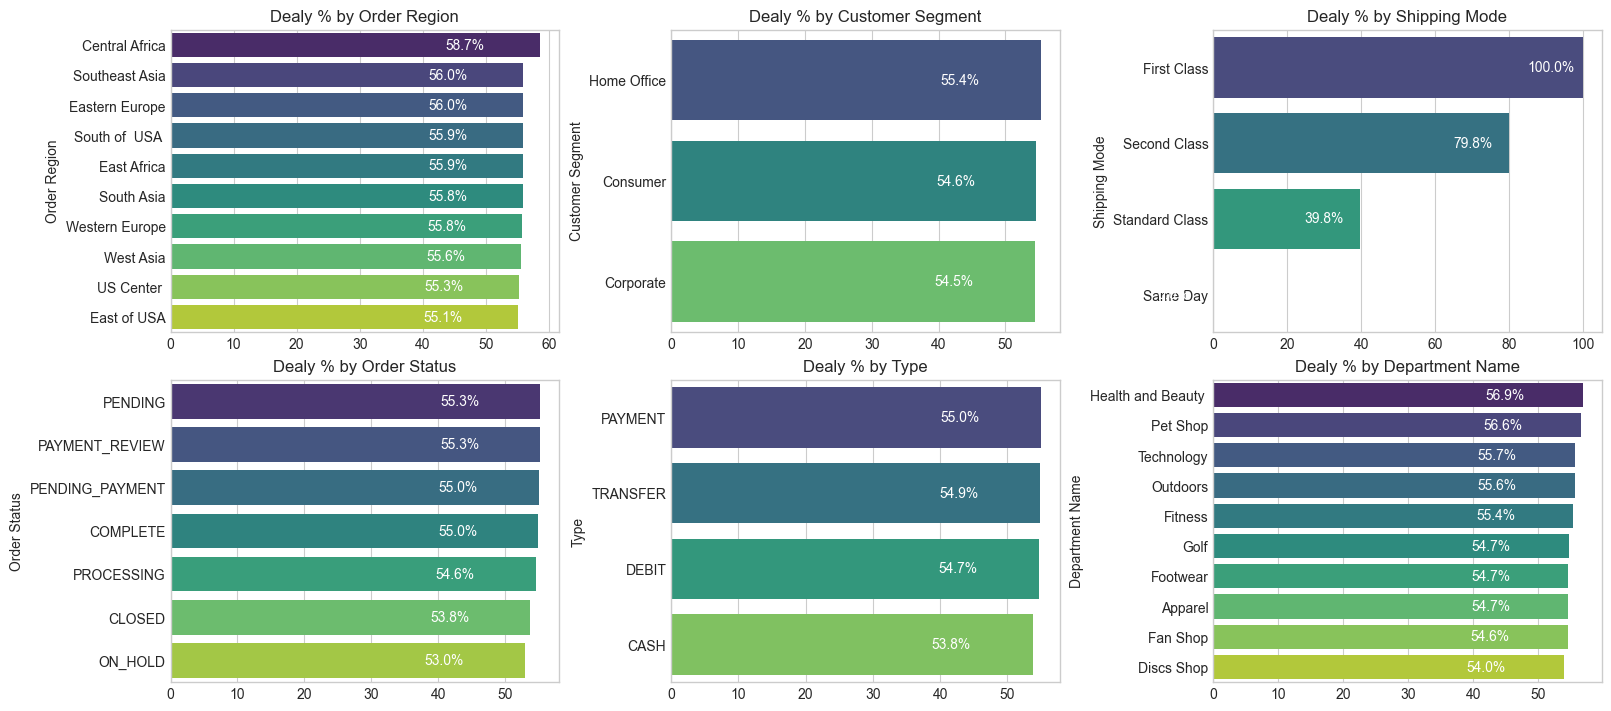

In [19]:
def compute_delay_pct_by_category(category):
    cat_df=df.groupby(category).agg(
        total_orders=('Delay','count'),
        late_orders=('Is_Delayed','sum')
    ).reset_index()
    cat_df['delay_pct']= cat_df['late_orders'] / cat_df['total_orders']*100
    cat_df= cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

categories= ['Order Region','Customer Segment','Shipping Mode','Order Status','Type', 'Department Name']

fig, axes= plt.subplots(2,3, figsize=(16,7), constrained_layout=True)
axes= axes.flatten()

for ax, category in zip(axes, categories):
    cat_df= compute_delay_pct_by_category(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    ax.set_title(f'Dealy % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] -15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color='white')
plt.savefig('Bottleneck Detection.png', dpi=300, bbox_inches='tight')
plt.show()

# Root Cause Analysis
Central Africa was selected for a deep-dive as the highest-delay region (**58.7%**). The chart above ranks the top 10 driver factors by delay percentage within this region.

**Findings:**
- **Payment friction stands out:** orders in `PAYMENT_REVIEW` status show an **80.0%** delay rate in Central Africa (vs. 55.3% overall) — a clear, fixable operational bottleneck rather than a shipping issue.
- **Outdoors (61.3%) and Golf (60.8%)** departments show significantly elevated delay rates within this region, pointing to a warehouse-level issue (stock availability, pick-and-pack time, or carrier assignment) rather than a demand-side problem.

<Figure size 640x480 with 0 Axes>

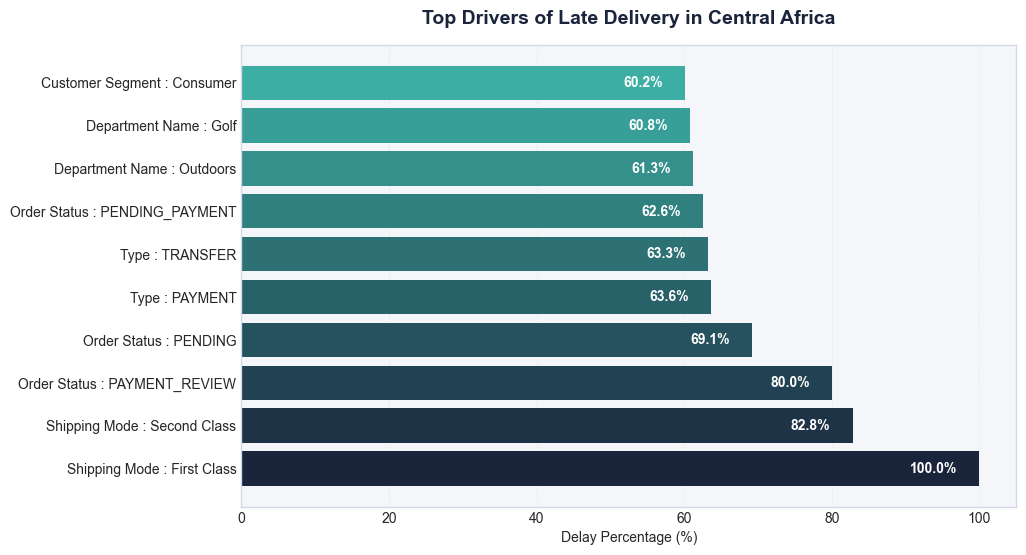

In [20]:
# top drivers of late delivety by region

def top_drivers_for_region(region):
    df_region= df[df['Order Region'] == region].copy()

    drivers= ['Shipping Mode','Customer Segment', 'Department Name', 'Type', 'Order Status']

    all_factors= []
    for factor in drivers:
        temp=(
            df_region.groupby(factor).agg(
                total_orders=('Delay','count'),
                late_orders=('Is_Delayed','sum'),
                avg_delay=('Delay','mean')
            )
            .reset_index()
        )

        temp['delay_pct']= temp['late_orders'] / temp['total_orders']*100
        temp['Driver']=factor
        temp['Factor_Level']= factor+ " : " + temp[factor].astype(str)

        all_factors.append(temp[['Driver','Factor_Level','delay_pct','avg_delay','total_orders']]) 

    # combine all drivers
    final_df= pd.concat(all_factors)

    # top 10 drivers
    top_factors= final_df.sort_values('delay_pct', ascending=False).head(10)
    plt.figure()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_facecolor('#F4F6F9') 
    fig.patch.set_facecolor('#FFFFFF')

    cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", ["#1A243B", "#3CAEA3"])
    colors = cmap(np.linspace(0, 1, len(top_factors)))

    bars = ax.barh(top_factors['Factor_Level'], top_factors['delay_pct'], color=colors)

    ax.set_xlabel("Delay Percentage (%)")
    ax.set_ylabel("") # Removed to match image
    ax.set_title(f"Top Drivers of Late Delivery in {region}", 
                 fontsize=14, fontweight='bold', color='#1A243B', pad=15)
    
    ax.grid(axis='x', linestyle=':', alpha=0.5, color='#d3d3d3')
    ax.grid(axis='y', visible=False) 
    
    for spine in ax.spines.values():
        spine.set_color('#D1D9E6')

    for bar in bars:
        width = bar.get_width()
        # offset slightly from the right edge
        ax.text(width - 3, bar.get_y() + bar.get_height() / 2,
                f"{width:.1f}%",
                va='center', ha='right', fontsize=10, color='white', fontweight='bold'
        )
    plt.savefig('Root Cause Analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Test the function
top_drivers_for_region('Central Africa')

# Time-Based Analysis
Delay rate was analyzed across three temporal dimensions: month, day of week, and hour of day.

**Findings:**
- **Seasonality exists but is modest:** delay rates stay within a **53–57%** band across all time dimensions, with August/September (**55.4%**) and December (**55.2%**) as peak months — consistent with mid-year promotions and Q4 holiday surge. July is the seasonal low point (~53.75%), confirming this variation is plannable rather than random.
- **Day-of-week barely matters:** Monday (55.5%) and Sunday (55.2%) peak, but the full weekly spread is under 1 percentage point — not a meaningful lever for intervention.
- **Hour of day shows the clearest peaks:** Hour 21 (**57.1%**), Hour 11 (**56.7%**), and Hour 12 (**56.0%**) are the worst windows — late-evening orders likely hit processing cutoffs, while midday peaks reflect volume bottlenecks.

In [21]:
# Delay % by Month, Day of Week, Hour

delay_by_month=(
    df.groupby('order_month')['Is_Delayed'].mean()
    .reset_index()
)
delay_by_month['delay_pct']= delay_by_month['Is_Delayed']*100

delay_by_day=(
    df.groupby('order_day')['Is_Delayed'].mean()
    .reset_index()
)
delay_by_day['delay_pct']= delay_by_day['Is_Delayed']*100

delay_by_hour=(
    df.groupby('order_hour')['Is_Delayed'].mean()
    .reset_index()
)
delay_by_hour['delay_pct']= delay_by_hour['Is_Delayed']*100

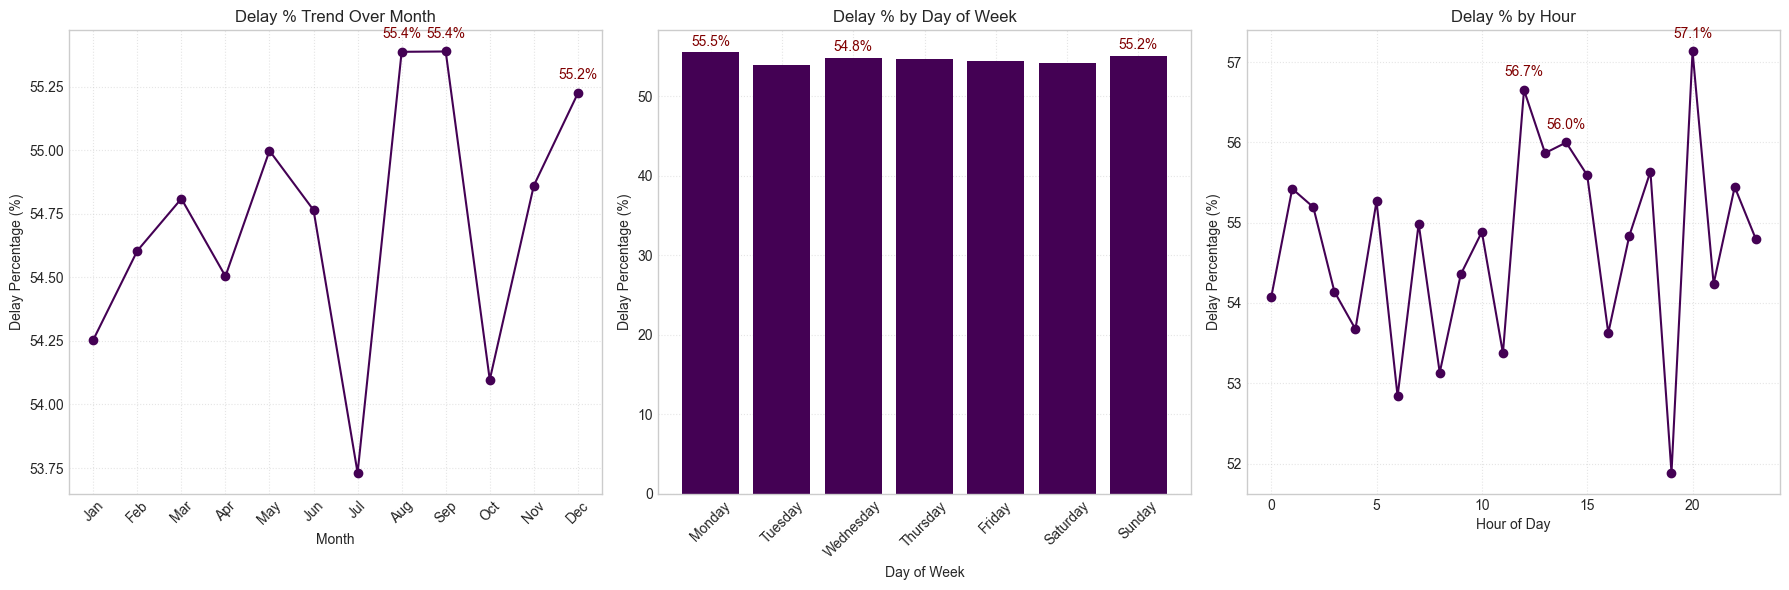

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

plt.tight_layout()
plt.savefig('Time-Based Analysis.png', dpi=300, bbox_inches='tight')
plt.show()